# Process discovery and Pareto-based model quality

Compare frequency-filtered directly-follows models using held-out fitness, precision, simplicity, and temporal stability. The objective is not to discover one universally best model, but to justify a non-dominated model for a stated purpose.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while not (root / 'labs').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
from labs.common import load_module, load_variant_lab
lab = load_module('discovery_quality_lab', root / 'labs/02-discovery-model-quality/discovery_quality_lab.py')
events = load_variant_lab().generate_event_log()
candidates = lab.discover_candidates(events)
display(candidates)

,candidate,threshold_share,edges,fitness,precision,simplicity,stability,pareto
0,frequency >= 0%,0.00,10,1.000000,1.000000,0.000000,0.968678,True
1,frequency >= 3%,0.03,10,1.000000,1.000000,0.000000,0.968678,False
2,frequency >= 8%,0.08,9,0.964286,0.979021,0.111111,0.971886,True
3,frequency >= 15%,0.15,7,0.916667,0.919580,0.333333,0.978025,True
4,frequency >= 25%,0.25,3,0.763095,0.734266,0.777778,0.992925,True


,candidate,threshold_share,edges,fitness,precision,simplicity,stability,pareto
0,frequency >= 0%,0.00,10,1.000000,1.000000,0.000000,0.968678,True
2,frequency >= 8%,0.08,9,0.964286,0.979021,0.111111,0.971886,True
3,frequency >= 15%,0.15,7,0.916667,0.919580,0.333333,0.978025,True
4,frequency >= 25%,0.25,3,0.763095,0.734266,0.777778,0.992925,True


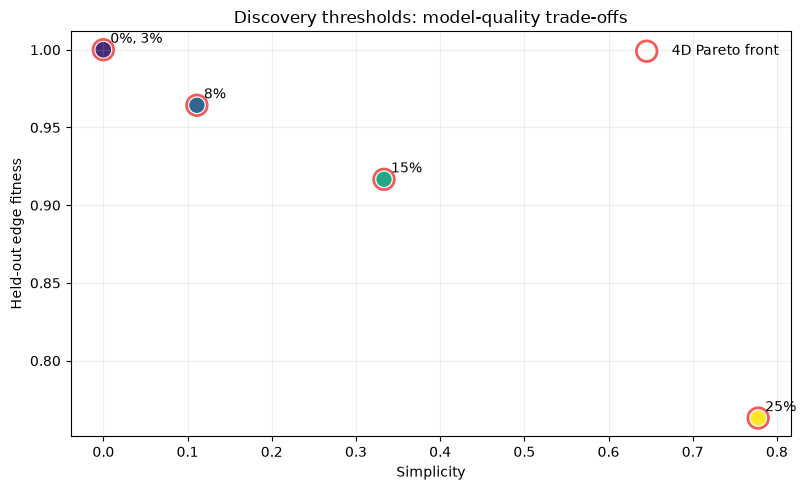

In [2]:
lab.plot_candidates(candidates)
pareto_front = candidates[candidates['pareto']]
display(pareto_front)

## Visualize the discovered process versions with PM4Py

The Pareto scores above are useful for ranking, but they hide *what the
model actually looks like*. Render each frequency-filtered candidate as a
directly-follows graph with PM4Py to see what each threshold keeps or
discards: which edges disappear first, and whether a discarded edge (e.g.
a rare exception path) is one you would defend keeping anyway.



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




frequency >= 0% — 10 edges — Pareto


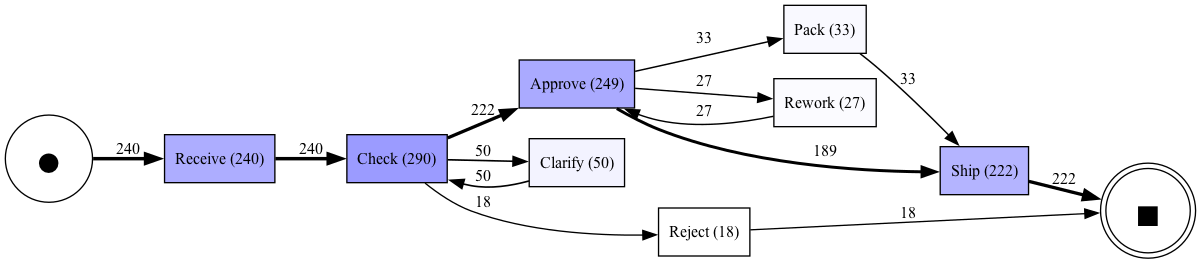

frequency >= 3% — 10 edges — dominated


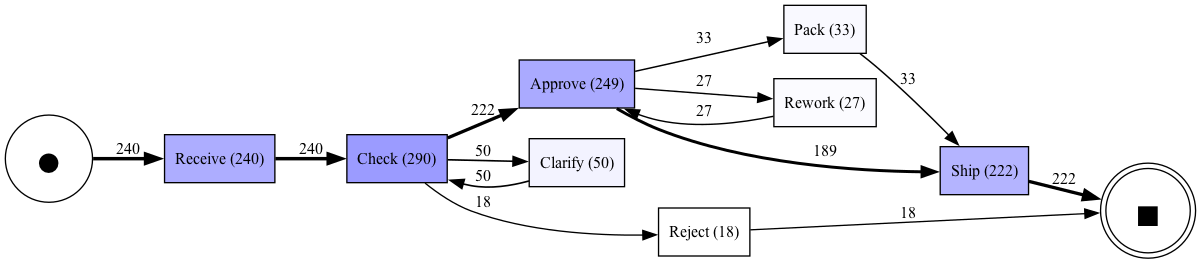

frequency >= 8% — 9 edges — Pareto


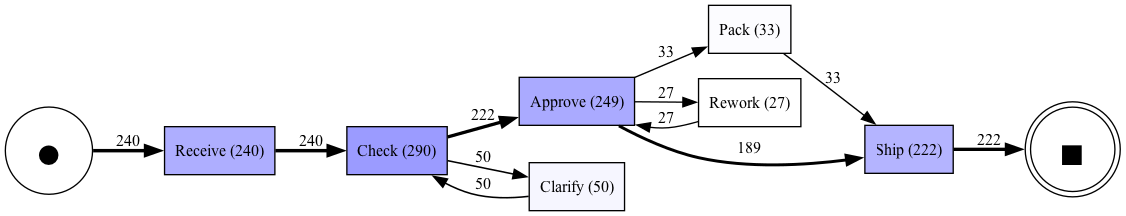

frequency >= 15% — 7 edges — Pareto


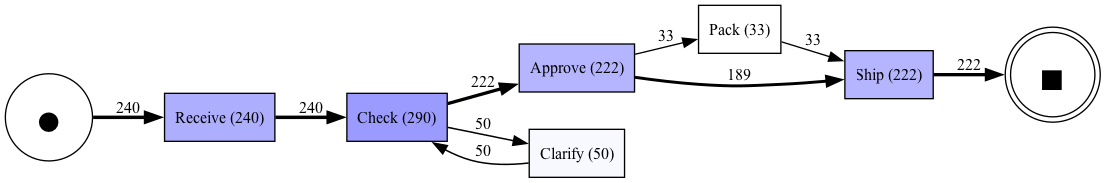

frequency >= 25% — 3 edges — Pareto


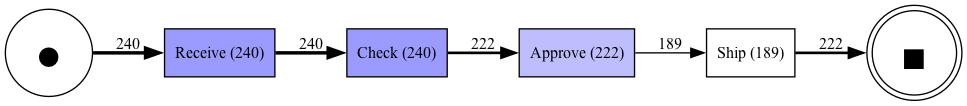

In [3]:
import pm4py
from IPython.display import Image, display

pm_log = pm4py.format_dataframe(
    events.query("lifecycle == 'complete'").copy(),
    case_id="case_id",
    activity_key="activity",
    timestamp_key="timestamp",
)
full_dfg, start_activities, end_activities = pm4py.discover_dfg(pm_log)
edge_sets = lab.discover_edge_sets(events)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

for _, row in candidates.iterrows():
    threshold = row["threshold_share"]
    kept_edges = edge_sets[threshold]
    filtered_dfg = {edge: count for edge, count in full_dfg.items() if edge in kept_edges}
    nodes = {activity for edge in filtered_dfg for activity in edge}
    filtered_start = {activity: count for activity, count in start_activities.items() if activity in nodes}
    filtered_end = {activity: count for activity, count in end_activities.items() if activity in nodes}

    image_path = output_dir / f"dfg_{threshold:.2f}.png"
    pm4py.save_vis_dfg(filtered_dfg, filtered_start, filtered_end, str(image_path))

    marker = "Pareto" if row["pareto"] else "dominated"
    print(f"{row['candidate']} — {row['edges']} edges — {marker}")
    display(Image(filename=str(image_path)))

## Selection exercise

1. Apply a minimum held-out fitness constraint.
2. Compare what each adjacent Pareto candidate gains and loses.
3. Choose one model for explanation and another for anomaly screening.
4. Explain why a weighted average should come only after feasibility and Pareto filtering.